# Riparian hotspots — statewide run, on Colab

Cell 1 installs, cell 2 points at your code, cells 3–6 run.

**Put the five `fl_*.py` files somewhere on Drive** (a `code/` folder beside
your project folder is the usual arrangement) and set `CODE_DIR` in cell 2.

Nothing in this notebook makes a decision. Every switch is in `fl_config.py`,
and `COLAB` in §0 is the one that puts the build on local disk and the finished
copy back on Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# 1. Dependencies. Colab has most of these; pyogrio is the one that matters,
#    because it is what pushes the state filter down into the national CSB file.
!pip -q install geopandas pyogrio mapclassify

# 2. Set script and project directories.

import os, sys

CODE_DIR    = '/content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/scripts'          # the fl_*.py files
PROJECT_DIR = '/content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY'

os.environ['FL_PROJECT_DIR'] = PROJECT_DIR
os.environ['FL_STATE_FIPS']  = '21'        # '47' Tennessee, '01' Alabama, ...
# os.environ['FL_COUNTIES']  = '047,225'   # uncomment for a two-county test run

sys.path.insert(0, CODE_DIR)
os.chdir(CODE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 2b. Stage the big read-only files onto local disk.
#
# Reading a GeoPackage is SQLite doing thousands of small random reads, and
# Drive is a FUSE mount where each one is a network round trip. One sequential
# copy is the access pattern Drive IS good at; everything after it is local SSD.
#
# MUST run before `from fl_config import ...` — fl_config resolves CACHE at
# import time and prefers /content/clipped_layers when the file is there.
# Idempotent: copies only what is missing, deletes nothing.

import glob, shutil, time

SRC_CLIP = os.path.join(PROJECT_DIR, 'clipped_layers')
DST_CLIP = '/content/clipped_layers'
SRC_SURF = os.path.join(PROJECT_DIR, 'outputs_statewide', '_state', 'output')
DST_SURF = '/content/outputs_statewide/_state/output'


def stage(src, dst):
    name = os.path.basename(dst)
    if not os.path.exists(src):
        print(f'  not on Drive     {name}'); return
    if os.path.exists(dst):
        print(f'  already local    {name}'); return
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    mb, t0 = os.path.getsize(src) / 1e6, time.time()
    shutil.copy2(src, dst)
    ok = os.path.getsize(dst) == os.path.getsize(src)
    print(f'  copied {mb:9,.0f} MB in {time.time() - t0:5.0f}s  {name}'
          + ('' if ok else '   <- SIZE MISMATCH: delete it and re-run'))


print('staging read-only inputs to local disk')
for _p in sorted(glob.glob(os.path.join(SRC_CLIP, '*_state_layers.gpkg'))):
    stage(_p, os.path.join(DST_CLIP, os.path.basename(_p)))
for _p in sorted(glob.glob(os.path.join(SRC_SURF, 'state_surface.*'))):
    stage(_p, os.path.join(DST_SURF, os.path.basename(_p)))

# Now, and only now, import.
from fl_config import describe, CACHE
describe()
assert CACHE.startswith('/content/clipped_layers'), (
    f'cache is still being read over Drive:\n  {CACHE}\n'
    f'the copy above did not land where fl_config looks')

staging read-only inputs to local disk
  already local    ky_state_layers.gpkg
  already local    state_surface.gpkg
  already local    state_surface.json
CONFIGURATION
  running on   Google Colab  (Drive mounted, building on local disk)
  project      /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY
  raw inputs   /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/raw_data
  cache        /content/clipped_layers/ky_state_layers.gpkg
  outputs      /content/outputs_statewide
               -> copied at the end to /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/outputs_statewide
  switches     RUN_PREPROCESS='auto'  RUN_SURFACE='auto'  RUN_PASS_C=True  SURFACE_GUARD=True
  study area   state 21 (Kentucky, KY) · counties all · extent whole_county
  surface      1-mile cells · 3-mile band · 100 ft buffer · 40 km tiles
  threshold    basis county · r

## Preprocessing — run once

Cuts the national and statewide downloads to the state and writes one cached
GeoPackage. Tens of minutes, almost all of it reading CSB. Once the cache
exists, `RUN_PREPROCESS = 'auto'` skips everything that is still current.

fl_common ready | geopandas 1.2.0 | shapely 2.1.2 | pyogrio
CONFIGURATION
  running on   Google Colab  (Drive mounted, building on local disk)
  project      /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY
  raw inputs   /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/raw_data
  cache        /content/clipped_layers/ky_state_layers.gpkg
  outputs      /content/outputs_statewide
               -> copied at the end to /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/outputs_statewide
  switches     RUN_PREPROCESS='auto'  RUN_SURFACE='auto'  RUN_PASS_C=True  SURFACE_GUARD=True
  study area   state 21 (Kentucky, KY) · counties all · extent whole_county
  surface      1-mile cells · 3-mile band · 100 ft buffer · 40 km tiles
  threshold    basis county · ratio 1.5x · floor knee (knee, 'marginal' rule)
  parcels      floor 2 ac · W_PLACE 0.75 · ranke

/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))


   dataset found     MB                                                      file                                                    layers
    cousub   yes   15.3                                     tl_2025_21_cousub.shp                                                          
        pa   yes   23.6                                             ACF_PA_25.shp                                                          
watersheds   yes   74.7                                Priority_HUC8_Internal.shp                                                          
       csb   yes    NaN                                               CSB1825.gdb                                         national1825 [OK]
  nhd_flow   yes 1902.6                            NHD_H_Kentucky_State_GPKG.gpkg ExternalCrosswalk, NHDArea, NHDAreaEventFC, NHDFCode [OK]
    nhd_wb   yes 1902.6                            NHD_H_Kentucky_State_GPKG.gpkg ExternalCrosswalk, NHDArea, NHDAreaEventFC, NHDFCode [OK]
  nhd_area   yes 190

/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))
/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:320: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read_info(
/usr/local/lib/python3.13/dist-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


  nhd_flow       567,884 features  (pushdown: ftype IN (460, 558, 336); bbox)
               in the state: 567,884 -> 316,061 (whole features)
               cached as layer 'nhd_flow'
  nhd_wb       SOURCE HAS CHANGED since this layer was cached - rebuilding


/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))


  nhd_wb         272,659 features  (pushdown: bbox)
               in the state: 272,658 -> 193,173 (whole features)
               cached as layer 'nhd_wb'
  nhd_area     SOURCE HAS CHANGED since this layer was cached - rebuilding


/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))


  nhd_area         1,374 features  (pushdown: bbox)
               in the state: 1,374 -> 938 (whole features)
               cached as layer 'nhd_area'
  wetlands     SOURCE HAS CHANGED since this layer was cached - rebuilding
  wetlands       424,080 features  (pushdown: bbox)
               in the state: 424,080 -> 353,122 (whole features)
               cached as layer 'wetlands'
  huc12        SOURCE HAS CHANGED since this layer was cached - rebuilding
  huc12            1,850 features  (pushdown: bbox)
               in the state: 1,850 -> 1,301 (whole features)
               cached as layer 'huc12'
  pa_geo       cached as layer 'pa_geo'

in memory:
  counties     120 features
  cousub       493 features
  pa_geo       2 features
  watersheds   84 features
  csb          336,974 features
  nhd_flow     316,061 features
  nhd_wb       193,173 features
  nhd_area     938 features
  wetlands     353,122 features
  huc12        1,301 features

cropland: 4,038,695 ac across 336,974 

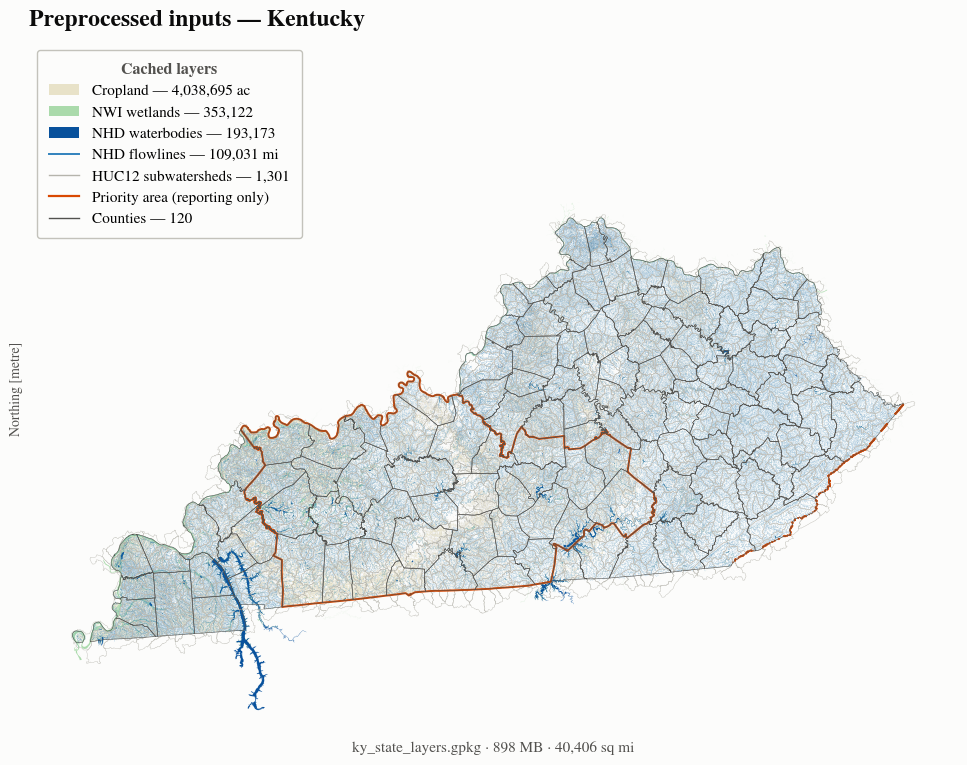

wrote /content/outputs_statewide/_preprocess/figures/cached_inputs.png

PREPROCESSING COMPLETE
  cache   /content/clipped_layers/ky_state_layers.gpkg
          898.1 MB
          layers: counties, cousub, csb, huc12, nhd_area, nhd_flow, nhd_wb, pa_geo, parcels_enriched, watersheds, wetlands

  Set RUN_PREPROCESS = False in fl_config.py to skip all of the above next time.
  Next: python fl_02_statewide.py

COPYING TO THE PROJECT FOLDER
  The equivalent commands, if you would rather do it by hand:
    cp -r "/content/outputs_statewide" "/content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/"
    cp -r "/content/clipped_layers/ky_state_layers.gpkg" "/content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/clipped_layers/"

  outputs: 352 files, 352 MB -> /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/outputs_statewide
    done in 141s - all 352 files verifie

<Figure size 640x480 with 0 Axes>

In [3]:
%run fl_01_preprocess.py

## The statewide analysis

Pass A (the density surface) is the expensive one and checkpoints every tile,
so a runtime reset costs one tile rather than the pass. Everything after Pass A re-runs in minutes
off the cached surface.

If the runtime drops, re-run cells 1–2b and then this cell; it picks up where it
stopped.

In [4]:
%run fl_02_statewide.py

Output hidden; open in https://colab.research.google.com to view.


STAKEHOLDER PACKAGE — Kentucky
  surface  /content/outputs_statewide/_state/output/state_surface.gpkg
  cache    /content/clipped_layers/ky_state_layers.gpkg
  package  /content/outputs_statewide/_state/package/ky_riparian_hotspots.gpkg
  integrity  both files pass PRAGMA quick_check

THE RESULT
  read 150 zones and 41,208 scored cells
  of those cells, 3,244 are hot (7.9%)
  added priority_rank / priority_tier (ordering of rip_crop_ac, presentational)
  hotspot_zones                150 features · 50 fields  <- the headline layer
  hotspot_cells              3,244 features · 14 fields  <- the cells the zones are made of

CONTEXT
  counties           120 features  (from cache)
  joined 6 county_summary field(s) onto the county boundaries
  counties                     120 features ·  8 fields  <- with the per-county result joined
  huc12            1,301 features  (from cache)
  huc12_subwatersheds        1,301 features ·  2 fields
  watersheds          84 features  (from cache)
  prio

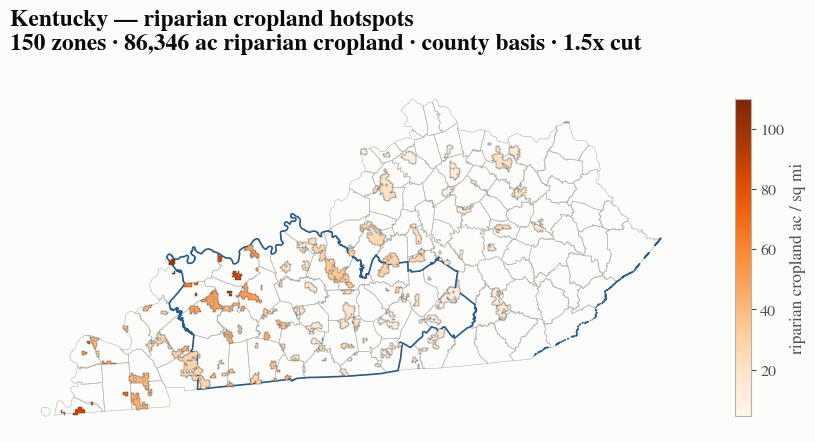

  wrote overview.png

PACKAGE
  layers    counties, hotspot_cells, hotspot_zones, huc12_subwatersheds, priority_area, priority_huc8, rivers_near_zones, streams_near_zones, waterbodies_near_zones, wetlands_near_zones
  gpkg      237.9 MB
  zip       132.1 MB  <- send this one

  /content/outputs_statewide/_state/package
    README.txt                                      0.0 MB
    data_dictionary.csv                             0.0 MB
    ky_riparian_hotspots.gpkg                     237.9 MB
    ky_riparian_hotspots_package.zip              132.1 MB
    overview.png                                    0.2 MB

COPYING TO THE PROJECT FOLDER
  The equivalent commands, if you would rather do it by hand:
    cp -r "/content/outputs_statewide" "/content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/"

  outputs: 492 files, 1,133 MB -> /content/drive/MyDrive/FergusonLynch/03_AtRiskSpeciesData/G3S3_update_EF/Parcel_priority_maps_KY/outputs_statewide
  

<Figure size 640x480 with 0 Axes>

In [6]:
%run fl_03_package.py

## Output location

`outputs_statewide/` in your project folder on Drive:

* `county_manifest.csv` — the run ledger. Start here.
* `_state/` — the surface, the state figures, the validation tables.
* `counties/<FIPS>_<Name>/` — one folder per county.

The build happens on `/content` (local disk) and is copied to Drive at the end,
because a GeoPackage written straight to a FUSE mount can lose layers without
raising.